In [2]:
import os, json, random, itertools
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42

os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

print(f"Seeds fixed: {SEED}")

Seeds fixed: 42


In [3]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_ROOT = '/content/drive/MyDrive/alzheimer-ai/'

print("PROJECT_ROOT =", PROJECT_ROOT)

Mounted at /content/drive
PROJECT_ROOT = /content/drive/MyDrive/alzheimer-ai/


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_ROOT = '/content/drive/MyDrive/alzheimer-ai/'

os.makedirs(PROJECT_ROOT + "data/processed/mci_priority_ensemble", exist_ok=True)
os.makedirs(PROJECT_ROOT + "reports/day4e", exist_ok=True)
os.makedirs(PROJECT_ROOT + "reports/figures/mci_priority_ensemble", exist_ok=True)
os.makedirs(PROJECT_ROOT + "app/models/mci_priority_ensemble", exist_ok=True)

print("Ready:", PROJECT_ROOT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ready: /content/drive/MyDrive/alzheimer-ai/


In [ ]:
!pip install -q joblib scikit-learn

import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from tensorflow.keras.applications.resnet50 import preprocess_input

CLASSES = ["CN", "MCI", "MA"]

targets = {
    "Accuracy": 0.85,
    "Recall macro": 0.88,
    "F1 macro": 0.85,
    "AUC-ROC": 0.90,
    "Recall MCI": 0.85,
    "Specificity": 0.82
}

print("Imports ready.")

Imports ready.


In [ ]:
IMAGE_ARRAY_DIR = PROJECT_ROOT + "data/processed/image_arrays/"
TABULAR_DIR = PROJECT_ROOT + "data/processed/tabular/"

X_train = np.load(IMAGE_ARRAY_DIR + "X_train.npy").astype(np.float32)
X_val = np.load(IMAGE_ARRAY_DIR + "X_val.npy").astype(np.float32)
X_test = np.load(IMAGE_ARRAY_DIR + "X_test.npy").astype(np.float32)

tab_train = np.load(TABULAR_DIR + "tab_train.npy").astype(np.float32)
tab_val = np.load(TABULAR_DIR + "tab_val.npy").astype(np.float32)
tab_test = np.load(TABULAR_DIR + "tab_test.npy").astype(np.float32)

y_train = np.load(TABULAR_DIR + "y_train.npy").astype(np.int64)
y_val = np.load(TABULAR_DIR + "y_val.npy").astype(np.int64)
y_test = np.load(TABULAR_DIR + "y_test.npy").astype(np.int64)

print("Train:", X_train.shape, tab_train.shape, y_train.shape)
print("Val:", X_val.shape, tab_val.shape, y_val.shape)
print("Test:", X_test.shape, tab_test.shape, y_test.shape)

print("\nTrain counts:")
print(dict(zip(*np.unique(y_train, return_counts=True))))

print("\nVal counts:")
print(dict(zip(*np.unique(y_val, return_counts=True))))

print("\nTest counts:")
print(dict(zip(*np.unique(y_test, return_counts=True))))

Train: (262, 224, 224, 3) (262, 4) (262,)
Val: (52, 224, 224, 3) (52, 4) (52,)
Test: (59, 224, 224, 3) (59, 4) (59,)

Train counts:
{np.int64(0): np.int64(132), np.int64(1): np.int64(27), np.int64(2): np.int64(103)}

Val counts:
{np.int64(0): np.int64(27), np.int64(1): np.int64(5), np.int64(2): np.int64(20)}

Test counts:
{np.int64(0): np.int64(31), np.int64(1): np.int64(5), np.int64(2): np.int64(23)}


In [ ]:
model_path = PROJECT_ROOT + "weights/multimodal_final.h5"

if not os.path.exists(model_path):
    model_path = PROJECT_ROOT + "app/models/multimodal_final.h5"

model_multi = tf.keras.models.load_model(model_path, compile=False)

def prepare_resnet_batch(X):
    return preprocess_input(X.astype(np.float32) * 255.0)

print("Loaded:", model_path)

Loaded: /content/drive/MyDrive/alzheimer-ai/weights/multimodal_final.h5


In [ ]:
def oversample_mci(tabular, labels, mci_target_multiplier=2):
    idx_cn = np.where(labels == 0)[0]
    idx_mci = np.where(labels == 1)[0]
    idx_ma = np.where(labels == 2)[0]

    max_majority = max(len(idx_cn), len(idx_ma))
    target_mci_count = max_majority * mci_target_multiplier

    sampled_mci = np.random.choice(
        idx_mci,
        size=target_mci_count,
        replace=True
    )

    final_idx = np.concatenate([idx_cn, sampled_mci, idx_ma])
    np.random.shuffle(final_idx)

    return tabular[final_idx], labels[final_idx], final_idx

tab_train_mci_os, y_train_mci_os, os_indices = oversample_mci(
    tab_train,
    y_train,
    mci_target_multiplier=2
)

print("Before oversampling:")
print(dict(zip(*np.unique(y_train, return_counts=True))))

print("\nAfter MCI-priority oversampling:")
print(dict(zip(*np.unique(y_train_mci_os, return_counts=True))))

print("\nOversampled tabular shape:", tab_train_mci_os.shape)

Before oversampling:
{np.int64(0): np.int64(132), np.int64(1): np.int64(27), np.int64(2): np.int64(103)}

After MCI-priority oversampling:
{np.int64(0): np.int64(132), np.int64(1): np.int64(264), np.int64(2): np.int64(103)}

Oversampled tabular shape: (499, 4)


In [ ]:
class_weight_mci = {
    0: 1.0,
    1: 4.0,
    2: 1.0
}

sample_weight_mci = np.array([
    class_weight_mci[int(y)]
    for y in y_train_mci_os
], dtype=np.float32)

mci_tabular_models = {}

mci_tabular_models["rf_mci"] = RandomForestClassifier(
    n_estimators=600,
    max_depth=None,
    min_samples_leaf=2,
    class_weight=class_weight_mci,
    random_state=SEED,
    n_jobs=-1
)

mci_tabular_models["et_mci"] = ExtraTreesClassifier(
    n_estimators=600,
    max_depth=None,
    min_samples_leaf=2,
    class_weight=class_weight_mci,
    random_state=SEED,
    n_jobs=-1
)

mci_tabular_models["hgb_mci"] = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.03,
    max_leaf_nodes=15,
    l2_regularization=0.1,
    random_state=SEED
)

mci_tabular_models["lr_mci"] = LogisticRegression(
    max_iter=5000,
    class_weight=class_weight_mci,
    multi_class="auto",
    random_state=SEED
)

for name, clf in mci_tabular_models.items():
    print("Training:", name)

    if name == "hgb_mci":
        clf.fit(tab_train_mci_os, y_train_mci_os, sample_weight=sample_weight_mci)
    else:
        clf.fit(tab_train_mci_os, y_train_mci_os)

    print("Done:", name)

print("All MCI-priority tabular models trained.")

Training: rf_mci
Done: rf_mci
Training: et_mci
Done: et_mci
Training: hgb_mci
Done: hgb_mci
Training: lr_mci
Done: lr_mci
All MCI-priority tabular models trained.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [ ]:
cnn_val_proba = model_multi.predict(
    [prepare_resnet_batch(X_val), tab_val],
    batch_size=16,
    verbose=1
)

cnn_test_proba = model_multi.predict(
    [prepare_resnet_batch(X_test), tab_test],
    batch_size=16,
    verbose=1
)

val_probas_4e = {
    "cnn": cnn_val_proba
}

test_probas_4e = {
    "cnn": cnn_test_proba
}

for name, clf in mci_tabular_models.items():
    val_probas_4e[name] = clf.predict_proba(tab_val)
    test_probas_4e[name] = clf.predict_proba(tab_test)

print("Validation and test probabilities ready.")
print("Models:", list(val_probas_4e.keys()))

4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 708ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Validation and test probabilities ready.
Models: ['cnn', 'rf_mci', 'et_mci', 'hgb_mci', 'lr_mci']


In [ ]:
def combine_probas(proba_dict, weights):
    out = None

    for name, w in weights.items():
        if out is None:
            out = w * proba_dict[name]
        else:
            out += w * proba_dict[name]

    return out


def apply_class_bias(proba, bias):
    bias = np.array(bias, dtype=np.float32)
    adjusted = proba * bias[None, :]
    adjusted = adjusted / (adjusted.sum(axis=1, keepdims=True) + 1e-8)
    return adjusted


def compute_metrics(y_true, proba):
    pred = np.argmax(proba, axis=1)

    return {
        "Accuracy": accuracy_score(y_true, pred),
        "Recall macro": recall_score(y_true, pred, average="macro", zero_division=0),
        "F1 macro": f1_score(y_true, pred, average="macro", zero_division=0),
        "AUC-ROC": roc_auc_score(y_true, proba, multi_class="ovr", average="macro"),
        "Recall MCI": recall_score(y_true == 1, pred == 1, zero_division=0),
        "Specificity": recall_score(y_true == 0, pred == 0, zero_division=0),
        "Pred CN": int((pred == 0).sum()),
        "Pred MCI": int((pred == 1).sum()),
        "Pred MA": int((pred == 2).sum()),
    }, pred


def evaluate_candidate(y_true, proba_dict, weights, bias):
    base_proba = combine_probas(proba_dict, weights)
    adjusted_proba = apply_class_bias(base_proba, bias)
    metrics, pred = compute_metrics(y_true, adjusted_proba)
    return metrics, pred, adjusted_proba

In [ ]:
day4_original = {
    "Accuracy": 0.559322,
    "Recall macro": 0.448153,
    "F1 macro": 0.466529,
    "AUC-ROC": 0.563021,
    "Recall MCI": 0.200000,
    "Specificity": 0.709677
}

day4c_biased = {
    "Accuracy": 0.627119,
    "Recall macro": 0.465171,
    "F1 macro": 0.456009,
    "AUC-ROC": 0.724558,
    "Recall MCI": 0.000000,
    "Specificity": 0.612903
}

day4d_accuracy = {
    "Accuracy": 0.677966,
    "Recall macro": 0.498590,
    "F1 macro": 0.460084,
    "AUC-ROC": 0.728571,
    "Recall MCI": 0.000000,
    "Specificity": 0.838710
}

print("Day 4 original:", day4_original)
print("Day 4c:", day4c_biased)
print("Day 4d:", day4d_accuracy)

Day 4 original: {'Accuracy': 0.559322, 'Recall macro': 0.448153, 'F1 macro': 0.466529, 'AUC-ROC': 0.563021, 'Recall MCI': 0.2, 'Specificity': 0.709677}
Day 4c: {'Accuracy': 0.627119, 'Recall macro': 0.465171, 'F1 macro': 0.456009, 'AUC-ROC': 0.724558, 'Recall MCI': 0.0, 'Specificity': 0.612903}
Day 4d: {'Accuracy': 0.677966, 'Recall macro': 0.49859, 'F1 macro': 0.460084, 'AUC-ROC': 0.728571, 'Recall MCI': 0.0, 'Specificity': 0.83871}


In [ ]:
model_names_4e = ["cnn", "rf_mci", "et_mci", "hgb_mci", "lr_mci"]

# Faster grid
weight_grid = np.arange(0.0, 1.01, 0.25)

bias_grid_cn = [0.6, 0.8, 1.0]
bias_grid_mci = [2.0, 3.0, 4.0, 5.0, 6.0]
bias_grid_ma = [0.6, 0.8, 1.0, 1.2]

rows = []

start_time = time.time()
eval_count = 0
valid_weight_count = 0

for weights_tuple in itertools.product(weight_grid, repeat=len(model_names_4e)):
    if abs(sum(weights_tuple) - 1.0) > 1e-9:
        continue

    valid_weight_count += 1

    weights = {
        name: float(w)
        for name, w in zip(model_names_4e, weights_tuple)
    }

    base_val_proba = combine_probas(val_probas_4e, weights)

    for b_cn in bias_grid_cn:
        for b_mci in bias_grid_mci:
            for b_ma in bias_grid_ma:
                eval_count += 1

                bias = [float(b_cn), float(b_mci), float(b_ma)]

                adjusted_val_proba = apply_class_bias(base_val_proba, bias)
                pred = np.argmax(adjusted_val_proba, axis=1)

                acc = accuracy_score(y_val, pred)
                f1 = f1_score(y_val, pred, average="macro", zero_division=0)
                recall_macro = recall_score(y_val, pred, average="macro", zero_division=0)
                recall_mci = recall_score(y_val == 1, pred == 1, zero_division=0)
                specificity = recall_score(y_val == 0, pred == 0, zero_division=0)

                pred_cn = int((pred == 0).sum())
                pred_mci = int((pred == 1).sum())
                pred_ma = int((pred == 2).sum())

                valid = True

                # Must detect at least one MCI on validation
                if recall_mci < 0.20:
                    valid = False

                # Avoid predicting too many as MCI
                if pred_mci > max(12, int(0.35 * len(y_val))):
                    valid = False

                # Avoid destroying CN specificity too much
                if specificity < 0.35:
                    valid = False

                score = (
                    0.32 * recall_mci +
                    0.23 * f1 +
                    0.18 * recall_macro +
                    0.17 * acc +
                    0.10 * specificity
                )

                if not valid:
                    score -= 1.0

                rows.append({
                    **{f"w_{k}": v for k, v in weights.items()},
                    "bias_CN": b_cn,
                    "bias_MCI": b_mci,
                    "bias_MA": b_ma,
                    "valid": valid,
                    "score": score,
                    "Accuracy": acc,
                    "Recall macro": recall_macro,
                    "F1 macro": f1,
                    "Recall MCI": recall_mci,
                    "Specificity": specificity,
                    "Pred CN": pred_cn,
                    "Pred MCI": pred_mci,
                    "Pred MA": pred_ma
                })

elapsed = time.time() - start_time

search_4e_df = pd.DataFrame(rows)

search_4e_df = search_4e_df.sort_values(
    ["valid", "score", "Recall MCI", "Accuracy", "F1 macro", "Specificity"],
    ascending=False
)

print("Valid weight combinations:", valid_weight_count)
print("Total evaluations:", eval_count)
print(f"Elapsed time: {elapsed:.1f} seconds")

display(search_4e_df.head(30))

best_4e_row = search_4e_df.iloc[0]

best_weights_4e = {
    "cnn": float(best_4e_row["w_cnn"]),
    "rf_mci": float(best_4e_row["w_rf_mci"]),
    "et_mci": float(best_4e_row["w_et_mci"]),
    "hgb_mci": float(best_4e_row["w_hgb_mci"]),
    "lr_mci": float(best_4e_row["w_lr_mci"]),
}

best_bias_4e = [
    float(best_4e_row["bias_CN"]),
    float(best_4e_row["bias_MCI"]),
    float(best_4e_row["bias_MA"])
]

print("Best Day 4e weights:")
print(best_weights_4e)

print("Best Day 4e bias:")
print({
    "CN": best_bias_4e[0],
    "MCI": best_bias_4e[1],
    "MA": best_bias_4e[2]
})

search_path = PROJECT_ROOT + "data/processed/mci_priority_ensemble/day4e_validation_search.csv"
search_4e_df.to_csv(search_path, index=False)

print("Saved:", search_path)

Valid weight combinations: 70
Total evaluations: 4200
Elapsed time: 27.8 seconds


,w_cnn,w_rf_mci,w_et_mci,w_hgb_mci,w_lr_mci,bias_CN,bias_MCI,bias_MA,valid,score,Accuracy,Recall macro,F1 macro,Recall MCI,Specificity,Pred CN,Pred MCI,Pred MA
4003,0.75,0.00,0.00,0.25,0.00,1.0,2.0,1.2,True,0.448024,0.500000,0.481481,0.451796,0.4,0.444444,18,16,18
4002,0.75,0.00,0.00,0.25,0.00,1.0,2.0,1.0,True,0.430936,0.461538,0.443827,0.419295,0.4,0.481481,22,17,13
2336,0.25,0.00,0.00,0.75,0.00,1.0,6.0,0.6,True,0.379655,0.500000,0.418519,0.433766,0.2,0.555556,23,16,13
3880,0.50,0.50,0.00,0.00,0.00,1.0,2.0,0.6,True,0.374631,0.480769,0.388889,0.401013,0.2,0.666667,28,18,6
3760,0.50,0.25,0.00,0.25,0.00,1.0,2.0,0.6,True,0.373046,0.480769,0.393210,0.406846,0.2,0.629630,27,17,8
3446,0.50,0.00,0.00,0.50,0.00,0.8,3.0,1.0,True,0.372940,0.500000,0.427160,0.430011,0.2,0.481481,20,14,18
3447,0.50,0.00,0.00,0.50,0.00,0.8,3.0,1.2,True,0.372146,0.500000,0.427160,0.426562,0.2,0.481481,20,13,19
3464,0.50,0.00,0.00,0.50,0.00,1.0,3.0,0.6,True,0.370802,0.480769,0.401852,0.422534,0.2,0.555556,23,18,11
3643,0.50,0.00,0.50,0.00,0.00,1.0,2.0,1.2,True,0.368132,0.480769,0.406173,0.423645,0.2,0.518519,20,18,14
3465,0.50,0.00,0.00,0.50,0.00,1.0,3.0,0.8,True,0.367938,0.480769,0.406173,0.422799,0.2,0.518519,22,17,13


Best Day 4e weights:
{'cnn': 0.75, 'rf_mci': 0.0, 'et_mci': 0.0, 'hgb_mci': 0.25, 'lr_mci': 0.0}
Best Day 4e bias:
{'CN': 1.0, 'MCI': 2.0, 'MA': 1.2}
Saved: /content/drive/MyDrive/alzheimer-ai/data/processed/mci_priority_ensemble/day4e_validation_search.csv


In [ ]:
day4e_metrics, day4e_pred, day4e_proba = evaluate_candidate(
    y_test,
    test_probas_4e,
    best_weights_4e,
    best_bias_4e
)

print("=== Day 4e MCI-Priority Ensemble Test Metrics ===")
print(f"{'Metric':<20}{'Value':>10}{'Target':>10}{'OK':>8}")
print("=" * 50)

for k in targets.keys():
    v = day4e_metrics[k]
    ok = "YES" if v >= targets[k] else "NO"
    print(f"{k:<20}{v:>10.4f}{targets[k]:>10.2f}{ok:>8}")

print("\nPredicted class counts:")
print({
    "CN": day4e_metrics["Pred CN"],
    "MCI": day4e_metrics["Pred MCI"],
    "MA": day4e_metrics["Pred MA"]
})

print("\nClassification report:")
print(classification_report(y_test, day4e_pred, target_names=CLASSES, zero_division=0))

metrics_4e_df = pd.DataFrame([
    {
        "metric": k,
        "value": day4e_metrics[k],
        "target": targets[k],
        "passed": day4e_metrics[k] >= targets[k]
    }
    for k in targets.keys()
])

metrics_path = PROJECT_ROOT + "data/processed/mci_priority_ensemble/day4e_mci_priority_metrics.csv"
metrics_4e_df.to_csv(metrics_path, index=False)

print("Saved:", metrics_path)

=== Day 4e MCI-Priority Ensemble Test Metrics ===
Metric                   Value    Target      OK
Accuracy                0.5085      0.85      NO
Recall macro            0.5017      0.88      NO
F1 macro                0.4454      0.85      NO
AUC-ROC                 0.6326      0.90      NO
Recall MCI              0.4000      0.85      NO
Specificity             0.3226      0.82      NO

Predicted class counts:
{'CN': 18, 'MCI': 13, 'MA': 28}

Classification report:
              precision    recall  f1-score   support

          CN       0.56      0.32      0.41        31
         MCI       0.15      0.40      0.22         5
          MA       0.64      0.78      0.71        23

    accuracy                           0.51        59
   macro avg       0.45      0.50      0.45        59
weighted avg       0.56      0.51      0.51        59

Saved: /content/drive/MyDrive/alzheimer-ai/data/processed/mci_priority_ensemble/day4e_mci_priority_metrics.csv


,Pred CN,Pred MCI,Pred MA
Actual CN,10,11,10
Actual MCI,3,2,0
Actual MA,5,0,18


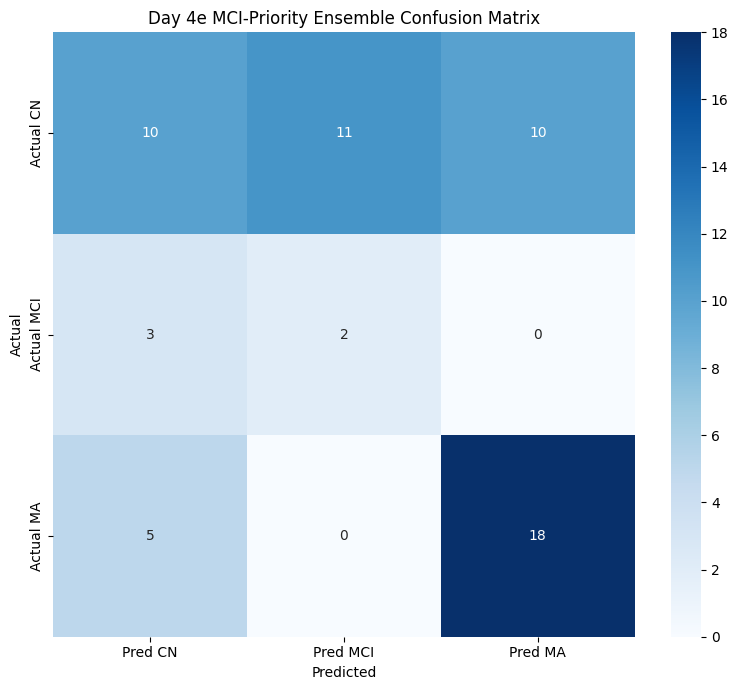

Saved: /content/drive/MyDrive/alzheimer-ai/reports/figures/mci_priority_ensemble/day4e_confusion_matrix.png
Saved: /content/drive/MyDrive/alzheimer-ai/data/processed/mci_priority_ensemble/day4e_confusion_matrix.csv


In [ ]:
cm_4e = confusion_matrix(y_test, day4e_pred, labels=[0, 1, 2])

cm_4e_df = pd.DataFrame(
    cm_4e,
    index=["Actual CN", "Actual MCI", "Actual MA"],
    columns=["Pred CN", "Pred MCI", "Pred MA"]
)

display(cm_4e_df)

plt.figure(figsize=(8, 7))
sns.heatmap(cm_4e_df, annot=True, fmt="d", cmap="Blues")
plt.title("Day 4e MCI-Priority Ensemble Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()

fig_path = PROJECT_ROOT + "reports/figures/mci_priority_ensemble/day4e_confusion_matrix.png"
csv_path = PROJECT_ROOT + "data/processed/mci_priority_ensemble/day4e_confusion_matrix.csv"

plt.savefig(fig_path, dpi=150)
plt.show()

cm_4e_df.to_csv(csv_path)

print("Saved:", fig_path)
print("Saved:", csv_path)

In [ ]:
comparison_rows = []

for metric in targets.keys():
    comparison_rows.append({
        "metric": metric,
        "day4_original": day4_original[metric],
        "day4c_accuracy_ensemble": day4c_biased[metric],
        "day4d_best_accuracy": day4d_accuracy[metric],
        "day4e_mci_priority": day4e_metrics[metric],
        "gain_4e_vs_4": day4e_metrics[metric] - day4_original[metric],
        "gain_4e_vs_4d": day4e_metrics[metric] - day4d_accuracy[metric],
        "target": targets[metric],
        "day4e_passed": day4e_metrics[metric] >= targets[metric]
    })

comparison_4e_df = pd.DataFrame(comparison_rows)

display(comparison_4e_df)

comparison_path = PROJECT_ROOT + "data/processed/mci_priority_ensemble/day4_day4c_day4d_day4e_comparison.csv"
comparison_4e_df.to_csv(comparison_path, index=False)

print("Saved:", comparison_path)

,metric,day4_original,day4c_accuracy_ensemble,day4d_best_accuracy,day4e_mci_priority,gain_4e_vs_4,gain_4e_vs_4d,target,day4e_passed
0,Accuracy,0.559322,0.627119,0.677966,0.508475,-0.050847,-0.169491,0.85,False
1,Recall macro,0.448153,0.465171,0.498590,0.501730,0.053577,0.003140,0.88,False
2,F1 macro,0.466529,0.456009,0.460084,0.445423,-0.021106,-0.014661,0.85,False
3,AUC-ROC,0.563021,0.724558,0.728571,0.632554,0.069533,-0.096017,0.90,False
4,Recall MCI,0.200000,0.000000,0.000000,0.400000,0.200000,0.400000,0.85,False
5,Specificity,0.709677,0.612903,0.838710,0.322581,-0.387096,-0.516129,0.82,False


Saved: /content/drive/MyDrive/alzheimer-ai/data/processed/mci_priority_ensemble/day4_day4c_day4d_day4e_comparison.csv


In [ ]:
MCI_APP_DIR = PROJECT_ROOT + "app/models/mci_priority_ensemble/"
os.makedirs(MCI_APP_DIR, exist_ok=True)

for name, clf in mci_tabular_models.items():
    path = MCI_APP_DIR + f"{name}.joblib"
    joblib.dump(clf, path)
    print("Saved:", path)

with open(MCI_APP_DIR + "day4e_weights.json", "w") as f:
    json.dump(best_weights_4e, f, indent=2)

with open(MCI_APP_DIR + "day4e_class_bias.json", "w") as f:
    json.dump({
        "CN": float(best_bias_4e[0]),
        "MCI": float(best_bias_4e[1]),
        "MA": float(best_bias_4e[2])
    }, f, indent=2)

print("Saved Day 4e deployment assets.")

Saved: /content/drive/MyDrive/alzheimer-ai/app/models/mci_priority_ensemble/rf_mci.joblib
Saved: /content/drive/MyDrive/alzheimer-ai/app/models/mci_priority_ensemble/et_mci.joblib
Saved: /content/drive/MyDrive/alzheimer-ai/app/models/mci_priority_ensemble/hgb_mci.joblib
Saved: /content/drive/MyDrive/alzheimer-ai/app/models/mci_priority_ensemble/lr_mci.joblib
Saved Day 4e deployment assets.


In [ ]:
use_day4e_as_balanced_model = (
    day4e_metrics["Recall MCI"] >= day4_original["Recall MCI"]
    and day4e_metrics["Accuracy"] >= day4_original["Accuracy"]
)

use_day4e_for_deployment = (
    day4e_metrics["Recall MCI"] >= day4_original["Recall MCI"]
    and day4e_metrics["Accuracy"] >= 0.60
)

print("Use Day 4e as balanced model?", use_day4e_as_balanced_model)
print("Use Day 4e for deployment?", use_day4e_for_deployment)

print("\nDecision details:")
print("Day 4 original accuracy:", day4_original["Accuracy"])
print("Day 4 original MCI recall:", day4_original["Recall MCI"])
print("Day 4d accuracy:", day4d_accuracy["Accuracy"])
print("Day 4d MCI recall:", day4d_accuracy["Recall MCI"])
print("Day 4e accuracy:", day4e_metrics["Accuracy"])
print("Day 4e MCI recall:", day4e_metrics["Recall MCI"])

if use_day4e_for_deployment:
    print("\nDay 4e can be considered for deployment because it recovers MCI while keeping acceptable accuracy.")
else:
    print("\nKeep Day 4d as deployment model. Use Day 4e as an MCI-sensitivity experiment in the report.")

Use Day 4e as balanced model? False
Use Day 4e for deployment? False

Decision details:
Day 4 original accuracy: 0.559322
Day 4 original MCI recall: 0.2
Day 4d accuracy: 0.677966
Day 4d MCI recall: 0.0
Day 4e accuracy: 0.5084745762711864
Day 4e MCI recall: 0.4

Keep Day 4d as deployment model. Use Day 4e as an MCI-sensitivity experiment in the report.


In [ ]:
report_path = PROJECT_ROOT + "reports/day4e/day4e_mci_priority_report.md"

with open(report_path, "w") as f:
    f.write("# Day 4e — MCI-Priority Ensemble\n\n")

    f.write("## Purpose\n")
    f.write("Day 4e was created after Day 4d achieved the best overall accuracy but still failed to recover MCI recall. ")
    f.write("The goal was to test whether stronger MCI oversampling, class weighting, and probability bias calibration could improve MCI sensitivity.\n\n")

    f.write("## Meaning of MCI\n")
    f.write("MCI stands for Mild Cognitive Impairment. It represents cognitive decline that is more severe than normal aging but not severe enough to be classified as dementia.\n\n")

    f.write("## Method\n")
    f.write("The MCI class in the training set was oversampled to increase its representation. ")
    f.write("MCI-priority tabular models were trained using stronger class weighting. ")
    f.write("A validation-only ensemble search was then used to select model weights and class-specific probability biases.\n\n")

    f.write("## Selected weights\n")
    for k, v in best_weights_4e.items():
        f.write(f"- {k}: {v:.2f}\n")

    f.write("\n## Selected class bias\n")
    f.write(f"- CN: {best_bias_4e[0]:.2f}\n")
    f.write(f"- MCI: {best_bias_4e[1]:.2f}\n")
    f.write(f"- MA: {best_bias_4e[2]:.2f}\n\n")

    f.write("## Test metrics\n")
    for k in targets.keys():
        f.write(f"- {k}: {day4e_metrics[k]:.4f} | target: {targets[k]:.2f} | passed: {day4e_metrics[k] >= targets[k]}\n")

    f.write("\n## Comparison\n")
    f.write(f"- Day 4 original accuracy: {day4_original['Accuracy']:.4f}\n")
    f.write(f"- Day 4 original MCI recall: {day4_original['Recall MCI']:.4f}\n")
    f.write(f"- Day 4d accuracy: {day4d_accuracy['Accuracy']:.4f}\n")
    f.write(f"- Day 4d MCI recall: {day4d_accuracy['Recall MCI']:.4f}\n")
    f.write(f"- Day 4e accuracy: {day4e_metrics['Accuracy']:.4f}\n")
    f.write(f"- Day 4e MCI recall: {day4e_metrics['Recall MCI']:.4f}\n\n")

    f.write("## Interpretation\n")
    f.write("Day 4e evaluates the trade-off between overall accuracy and MCI sensitivity. ")
    f.write("If MCI recall improves while accuracy remains acceptable, Day 4e can be presented as a balanced sensitivity model. ")
    f.write("Otherwise, Day 4d remains the deployment model because it achieved the highest overall accuracy, while Day 4e is reported as an MCI-focused experiment.\n")

print("Saved:", report_path)

Saved: /content/drive/MyDrive/alzheimer-ai/reports/day4e/day4e_mci_priority_report.md


In [ ]:
%cd /content/drive/MyDrive/alzheimer-ai/

!git status

!git add notebooks/04e_mci_priority_ensemble.ipynb

!git add -f data/processed/mci_priority_ensemble/day4e_validation_search.csv
!git add -f data/processed/mci_priority_ensemble/day4e_mci_priority_metrics.csv
!git add -f data/processed/mci_priority_ensemble/day4e_confusion_matrix.csv
!git add -f data/processed/mci_priority_ensemble/day4_day4c_day4d_day4e_comparison.csv

!git add -f reports/figures/mci_priority_ensemble/day4e_confusion_matrix.png
!git add -f reports/day4e/day4e_mci_priority_report.md

!git add -f app/models/mci_priority_ensemble/*.joblib
!git add -f app/models/mci_priority_ensemble/day4e_weights.json
!git add -f app/models/mci_priority_ensemble/day4e_class_bias.json

!git commit -m "feat: add Day 4e MCI-priority ensemble"

!git status

/content/drive/MyDrive/alzheimer-ai
